In [149]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import MultinomialNB
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [150]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan).fillna(df[cols].mean())
(df==0).sum().sum()

np.int64(611)

In [151]:
df['InsulinResistance'] = df['Glucose'] * df['Insulin']/405
df['AgeRisk'] = df['BMI'] * df['Age']

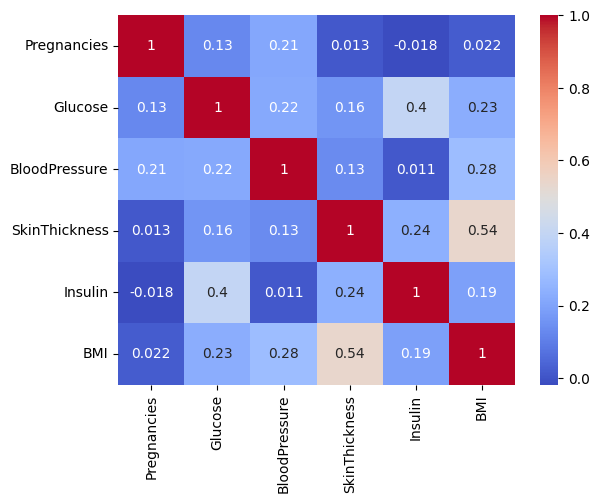

In [152]:
corr = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

<Axes: xlabel='Outcome'>

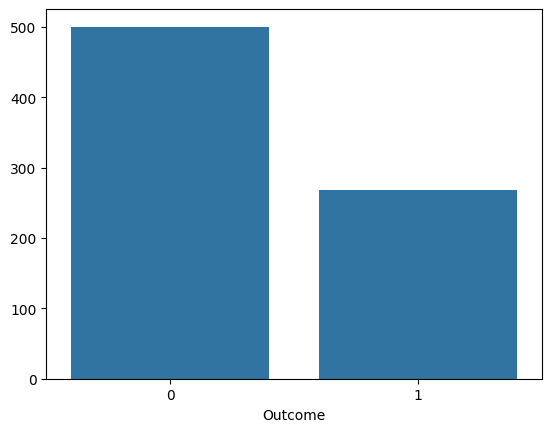

In [153]:
outcomeValues = df['Outcome'].value_counts()
sns.barplot(x=outcomeValues.index, y=outcomeValues.values)

In [154]:
X = df.drop(['Outcome'], axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

In [155]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [ ]:
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

ValueError: Negative values in data passed to MultinomialNB (input X).

In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome',
       'InsulinResistance', 'AgeRisk'],
      dtype='object')

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = gnb.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.85      0.80       100
           1       0.63      0.48      0.55        54

    accuracy                           0.72       154
   macro avg       0.69      0.67      0.67       154
weighted avg       0.71      0.72      0.71       154

[[85 15]
 [28 26]]


In [ ]:
pregnancies = float(input('Insert patient pregnancies:'))
glucose = float(input('Insert patient glucose level:'))
bloodpressure = float(input('Insert patient blood pressure:'))
skinthickness = float(input('Insert patient skin thickness:'))
insulin = float(input('Insert patient insulin level:'))
bmi = float(input('Insert patient bmi:'))
diabetespedigree = float(input('Insert patient diabetes pedigree function: '))
age = float(input('Insert patient age:'))


X_input = pd.DataFrame([{
    'Pregnancies': pregnancies,
    'Glucose': glucose,
    'BloodPressure': bloodpressure,
    'SkinThickness': skinthickness,
    'Insulin': insulin,
    'BMI': bmi,
    'DiabetesPedigreeFunction': diabetespedigree,
    'Age': age
}])

X_input['InsulinResistance'] = X_input['Glucose'] * X_input['Insulin']/405
X_input['AgeRisk'] = X_input['BMI'] * X_input['Age']


X_input_scaled = scaler.fit_transform(X_input)

y_input_pred = gnb.predict(X_input_scaled)
print(y_input_pred)

[0]
